# Análisis

In [ ]:
pip install category_encoders

In [2]:
import numpy  as np  
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn import preprocessing
import warnings
warnings.filterwarnings('ignore')

Cargamos el archivo y miramos su contenido

In [3]:
airbnb_data = pd.read_csv(
    "..\\..\\utils\\airbnb-listings-extract.csv",
    sep=';',
    encoding='utf-8'
)
print(airbnb_data.shape)
print(list(airbnb_data.columns))
airbnb_data.head(5)

(14780, 89)
['ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary', 'Space', 'Description', 'Experiences Offered', 'Neighborhood Overview', 'Notes', 'Transit', 'Access', 'Interaction', 'House Rules', 'Thumbnail Url', 'Medium Url', 'Picture Url', 'XL Picture Url', 'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Location', 'Host About', 'Host Response Time', 'Host Response Rate', 'Host Acceptance Rate', 'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood', 'Host Listings Count', 'Host Total Listings Count', 'Host Verifications', 'Street', 'Neighbourhood', 'Neighbourhood Cleansed', 'Neighbourhood Group Cleansed', 'City', 'State', 'Zipcode', 'Market', 'Smart Location', 'Country Code', 'Country', 'Latitude', 'Longitude', 'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Bed Type', 'Amenities', 'Square Feet', 'Price', 'Weekly Price', 'Monthly Price', 'Security Deposit', 'Cleaning Fee', 'Guests Included', 'Extra People', 'Minimum N

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,11210388,https://www.airbnb.com/rooms/11210388,20170306202425,2017-03-07,The Loft-Full Bath-Deck w/View,Loft in the Hill country 12-15 minutes directl...,This loft has a spectacular view of the hills ...,Loft in the Hill country 12-15 minutes directl...,none,This neighborhood is located in the hills west...,...,10.0,10.0,10.0,NaN,NaN,moderate,1.0,3.50,"30.3373609355,-97.8632766782","Host Is Superhost,Host Has Profile Pic,Host Id..."
1,17471131,https://www.airbnb.com/rooms/17471131,20170407214050,2017-04-08,"Claris I, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,10.0,8.0,10.0,HUTB-006721,NaN,super_strict_30,106.0,0.86,"41.3896829422,2.17262543017","Host Has Profile Pic,Requires License,Instant ..."
2,17584891,https://www.airbnb.com/rooms/17584891,20170407214050,2017-04-08,"Style Terrace Red, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,NaN,NaN,NaN,HUTB-007527,NaN,super_strict_30,106.0,NaN,"41.3930345489,2.16217327868","Host Has Profile Pic,Requires License,Instant ..."
3,5398030,https://www.airbnb.com/rooms/5398030,20170407214050,2017-04-08,Picasso Suite 1.4 Paseo de Gracia,Live like a local in Barcelona's most chic dis...,You wake up to the sun rising over Barcelona's...,Live like a local in Barcelona's most chic dis...,none,We're right in the heart of the chic L'Eixampl...,...,10.0,10.0,9.0,NaN,NaN,strict,24.0,1.09,"41.3969668101,2.1674178103","Host Has Profile Pic,Host Identity Verified,Re..."
4,18104606,https://www.airbnb.com/rooms/18104606,20170407214050,2017-04-08,Smart City Centre Apartment II,"Unique apartment in vibrant neighborhoods, car...","License: HUTB-005313 Charming apartment, locat...","Unique apartment in vibrant neighborhoods, car...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,flexible,92.0,NaN,"41.3886851936,2.15514963616","Host Has Profile Pic,Host Identity Verified,Is..."


Separamos train de test y leemos train para hacer el Analisis

In [4]:
train, test = train_test_split(airbnb_data, test_size=0.2, shuffle=True, random_state=26)
print(f'Dimensiones del dataset de training: {train.shape}')
print(f'Dimensiones del dataset de test: {test.shape}')
train.to_csv('..\\..\\utils\\airbnb-listings-extract-train.csv', sep=';', decimal='.', index=False)
test.to_csv('..\\..\\utils\\airbnb-listings-extract-test.csv', sep=';', decimal='.', index=False)
airbnb_train=pd.read_csv('..\\..\\utils\\airbnb-listings-extract-train.csv', sep=';', decimal='.')


Dimensiones del dataset de training: (11824, 89)
Dimensiones del dataset de test: (2956, 89)


Descartamos variables que no aportan poder predictivo. Eliminamos variables redundantes (como Geolocation, que ya está representada en Latitud/Longitud) y variables de varianza cero (como Country o City, dado que todas las observaciones pertenecen a Madrid).

In [5]:
columnas_a_borrar = [
    'ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary', 'Space', 
    'Description', 'Experiences Offered', 'Neighborhood Overview', 'Notes', 
    'Transit', 'Access', 'Interaction', 'House Rules', 'Thumbnail Url', 
    'Medium Url', 'Picture Url', 'XL Picture Url', 'Host ID', 'Host URL', 
    'Host Name', 'Host Since', 'Host Location', 'Host About', 
    'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood', 
    'Host Listings Count', 'Host Total Listings Count', 'Host Verifications', 
    'Street', 'Smart Location', 'Country Code', 'Country', 'City', 'State', 
    'Market', 'Calendar Updated', 'Calendar last Scraped', 'Geolocation'
]

airbnb_train = airbnb_train.drop(columns=columnas_a_borrar, errors='ignore')

Vemos nuestros datos desglosados

In [6]:
airbnb_train.describe()

,Host Response Rate,Latitude,Longitude,Accommodates,Bathrooms,Bedrooms,Beds,Square Feet,Price,Weekly Price,...,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month
count,10297.000000,11824.000000,11824.000000,11824.000000,11781.000000,11804.000000,11784.000000,470.000000,11812.000000,2902.000000,...,11824.000000,9200.000000,9181.000000,9187.000000,9174.000000,9185.000000,9171.000000,9171.000000,11822.000000,9315.000000
mean,94.751772,40.480997,-3.816740,3.276049,1.284950,1.342935,2.047946,394.063830,73.813241,377.063405,...,22.401133,91.758804,9.421958,9.335256,9.627425,9.652259,9.533966,9.223749,9.408222,1.861913
std,15.364231,4.750710,14.216027,2.097412,0.668915,0.894778,1.619597,655.686271,73.136658,195.284408,...,37.931934,8.953588,0.912592,0.986818,0.789011,0.762192,0.773200,0.949824,23.425537,1.867585
min,0.000000,-37.851182,-123.131344,1.000000,0.000000,0.000000,1.000000,0.000000,9.000000,70.000000,...,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.020000
25%,99.000000,40.409779,-3.707568,2.000000,1.000000,1.000000,1.000000,0.000000,34.000000,220.000000,...,1.000000,89.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,1.000000,0.450000
50%,100.000000,40.419676,-3.700751,3.000000,1.000000,1.000000,2.000000,95.000000,55.000000,350.000000,...,7.000000,94.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,2.000000,1.190000
75%,100.000000,40.430864,-3.683845,4.000000,1.000000,2.000000,2.000000,640.500000,86.000000,499.750000,...,27.000000,98.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000,2.740000
max,100.000000,55.966912,153.371427,16.000000,8.000000,10.000000,16.000000,6997.000000,999.000000,999.000000,...,376.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,145.000000,13.900000


Miramos cuantos nulos y en que columnas los tenemos

In [7]:
null_pct = airbnb_train.isnull().mean() * 100
null_pct.sort_values(ascending=False)

Has Availability                  99.923884
Host Acceptance Rate              99.780108
Jurisdiction Names                98.435386
License                           97.665765
Square Feet                       96.025034
Monthly Price                     75.972598
Weekly Price                      75.456698
Security Deposit                  57.713126
Cleaning Fee                      41.136671
Neighbourhood                     35.504060
Review Scores Value               22.437415
Review Scores Location            22.437415
Review Scores Checkin             22.412043
Review Scores Accuracy            22.352842
Review Scores Communication       22.319012
Review Scores Cleanliness         22.302097
Review Scores Rating              22.192152
Last Review                       21.228011
First Review                      21.219553
Reviews per Month                 21.219553
Host Response Rate                12.914411
Host Response Time                12.914411
Neighbourhood Group Cleansed    

Borramos los que tienen un número de nulos excesivamente altos ya que seria dificil rellenarlos y estarían muy sesgados a los que si tienen valores

In [8]:
airbnb_train=airbnb_train.drop(columns= [
    'Has Availability',
    'Host Acceptance Rate',
    'Jurisdiction Names',
    'License',
    'Square Feet',
    'Weekly Price',
    'Monthly Price',
])

Aplicamos transformaciones a las columnas para rellenar los nulos en función el por qué creemos que hay estos nulos, por ejemplo en security deposit creemos que no contienen Fianza mientras que en otros simplemente faltan valores y los calculamos mediante la mediana

In [9]:

cols = [
        'Review Scores Rating',
        'Review Scores Accuracy',
        'Review Scores Cleanliness',
        'Review Scores Checkin',
        'Review Scores Communication',
        'Review Scores Location',
        'Review Scores Value',
        'Bathrooms',
        'Beds',
        'Bedrooms',
        'Calculated host listings count',
        'Host Response Rate',
]

for col in cols:
    airbnb_train[col] = airbnb_train[col].fillna(airbnb_train[col].median())

cols_0= [
        'Security Deposit',
        'Cleaning Fee',
        'Reviews per Month'
]
for col in cols_0:
    airbnb_train[col] = airbnb_train[col].fillna(0)

cols_Unknown =[
        'Neighbourhood',
        'Neighbourhood Group Cleansed',
        'Zipcode',
        'Host Response Time'
]
for col in cols_Unknown:
    airbnb_train[col] = airbnb_train[col].fillna('Unknown')

airbnb_train['Amenities'] = airbnb_train['Amenities'].fillna('')
    
airbnb_train = airbnb_train.dropna(subset=['Price'])


Aplicamos Feature Engineering para extraer más valor de nuestros datos. Por un lado, transformamos las variables temporales (First Review, Last Review) en variables numéricas continuas, calculando los días transcurridos hasta la actualidad (imputando los nulos con -1 o el valor máximo). Por otro lado, convertimos las variables de texto plano (Amenities, Features) en variables numéricas contando el número total de servicios que ofrece cada alojamiento.

In [10]:

airbnb_train['Last Review'] = pd.to_datetime(airbnb_train['Last Review'], errors='coerce')
airbnb_train['First Review'] = pd.to_datetime(airbnb_train['First Review'], errors='coerce')


today = pd.to_datetime('today')

airbnb_train['Last Review'] = (today - airbnb_train['Last Review']).dt.days
airbnb_train['First Review'] = (today - airbnb_train['First Review']).dt.days


airbnb_train['Last Review'] = airbnb_train['Last Review'].fillna(-1)
airbnb_train['First Review'] = airbnb_train['First Review'].fillna(-1)

cols_to_count = ['Features', 'Amenities']

for col in cols_to_count:
    airbnb_train[col] = airbnb_train[col].fillna('').apply(lambda x: len(str(x).split(',')) if x != '' else 0)

In [11]:
print(airbnb_data.columns)

Index(['ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary',
       'Space', 'Description', 'Experiences Offered', 'Neighborhood Overview',
       'Notes', 'Transit', 'Access', 'Interaction', 'House Rules',
       'Thumbnail Url', 'Medium Url', 'Picture Url', 'XL Picture Url',
       'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Location',
       'Host About', 'Host Response Time', 'Host Response Rate',
       'Host Acceptance Rate', 'Host Thumbnail Url', 'Host Picture Url',
       'Host Neighbourhood', 'Host Listings Count',
       'Host Total Listings Count', 'Host Verifications', 'Street',
       'Neighbourhood', 'Neighbourhood Cleansed',
       'Neighbourhood Group Cleansed', 'City', 'State', 'Zipcode', 'Market',
       'Smart Location', 'Country Code', 'Country', 'Latitude', 'Longitude',
       'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Bedrooms',
       'Beds', 'Bed Type', 'Amenities', 'Square Feet', 'Price', 'Weekly Price',
       'Month

Revisamos que no nos queden nulos

In [12]:
null_pct = airbnb_train.isnull().mean() * 100
null_pct.sort_values(ascending=False)

Host Response Time                0.0
Minimum Nights                    0.0
Availability 30                   0.0
Availability 60                   0.0
Availability 90                   0.0
Availability 365                  0.0
Number of Reviews                 0.0
First Review                      0.0
Last Review                       0.0
Review Scores Rating              0.0
Review Scores Accuracy            0.0
Review Scores Cleanliness         0.0
Review Scores Checkin             0.0
Review Scores Communication       0.0
Review Scores Location            0.0
Review Scores Value               0.0
Cancellation Policy               0.0
Calculated host listings count    0.0
Reviews per Month                 0.0
Maximum Nights                    0.0
Extra People                      0.0
Host Response Rate                0.0
Guests Included                   0.0
Neighbourhood                     0.0
Neighbourhood Cleansed            0.0
Neighbourhood Group Cleansed      0.0
Zipcode     

Vemos nuestro Data frame ahora sin nulos y con transformacion realizadas

In [13]:
airbnb_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Host Response Rate,11812.0,95.434304,14.438598,0.000000,100.000000,100.000000,100.000000,100.000000
Latitude,11812.0,40.476540,4.746318,-37.851182,40.409779,40.419672,40.430846,55.966912
Longitude,11812.0,-3.822069,14.220601,-123.131344,-3.707576,-3.700770,-3.683942,153.371427
Accommodates,11812.0,3.273366,2.094950,1.000000,2.000000,3.000000,4.000000,16.000000
Bathrooms,11812.0,1.282679,0.664269,0.000000,1.000000,1.000000,1.000000,8.000000
Bedrooms,11812.0,1.341094,0.891770,0.000000,1.000000,1.000000,2.000000,10.000000
Beds,11812.0,2.046478,1.615255,1.000000,1.000000,2.000000,2.000000,16.000000
Amenities,11812.0,14.282679,4.886235,0.000000,11.000000,14.000000,17.000000,39.000000
Price,11812.0,73.813241,73.136658,9.000000,34.000000,55.000000,86.000000,999.000000
Security Deposit,11812.0,80.490264,120.696126,0.000000,0.000000,0.000000,150.000000,990.000000


Hacemos una gráfica en escala logaritmica para poder visualizar todos los valores con posibles outliers para hacer limpieza de estos outliers

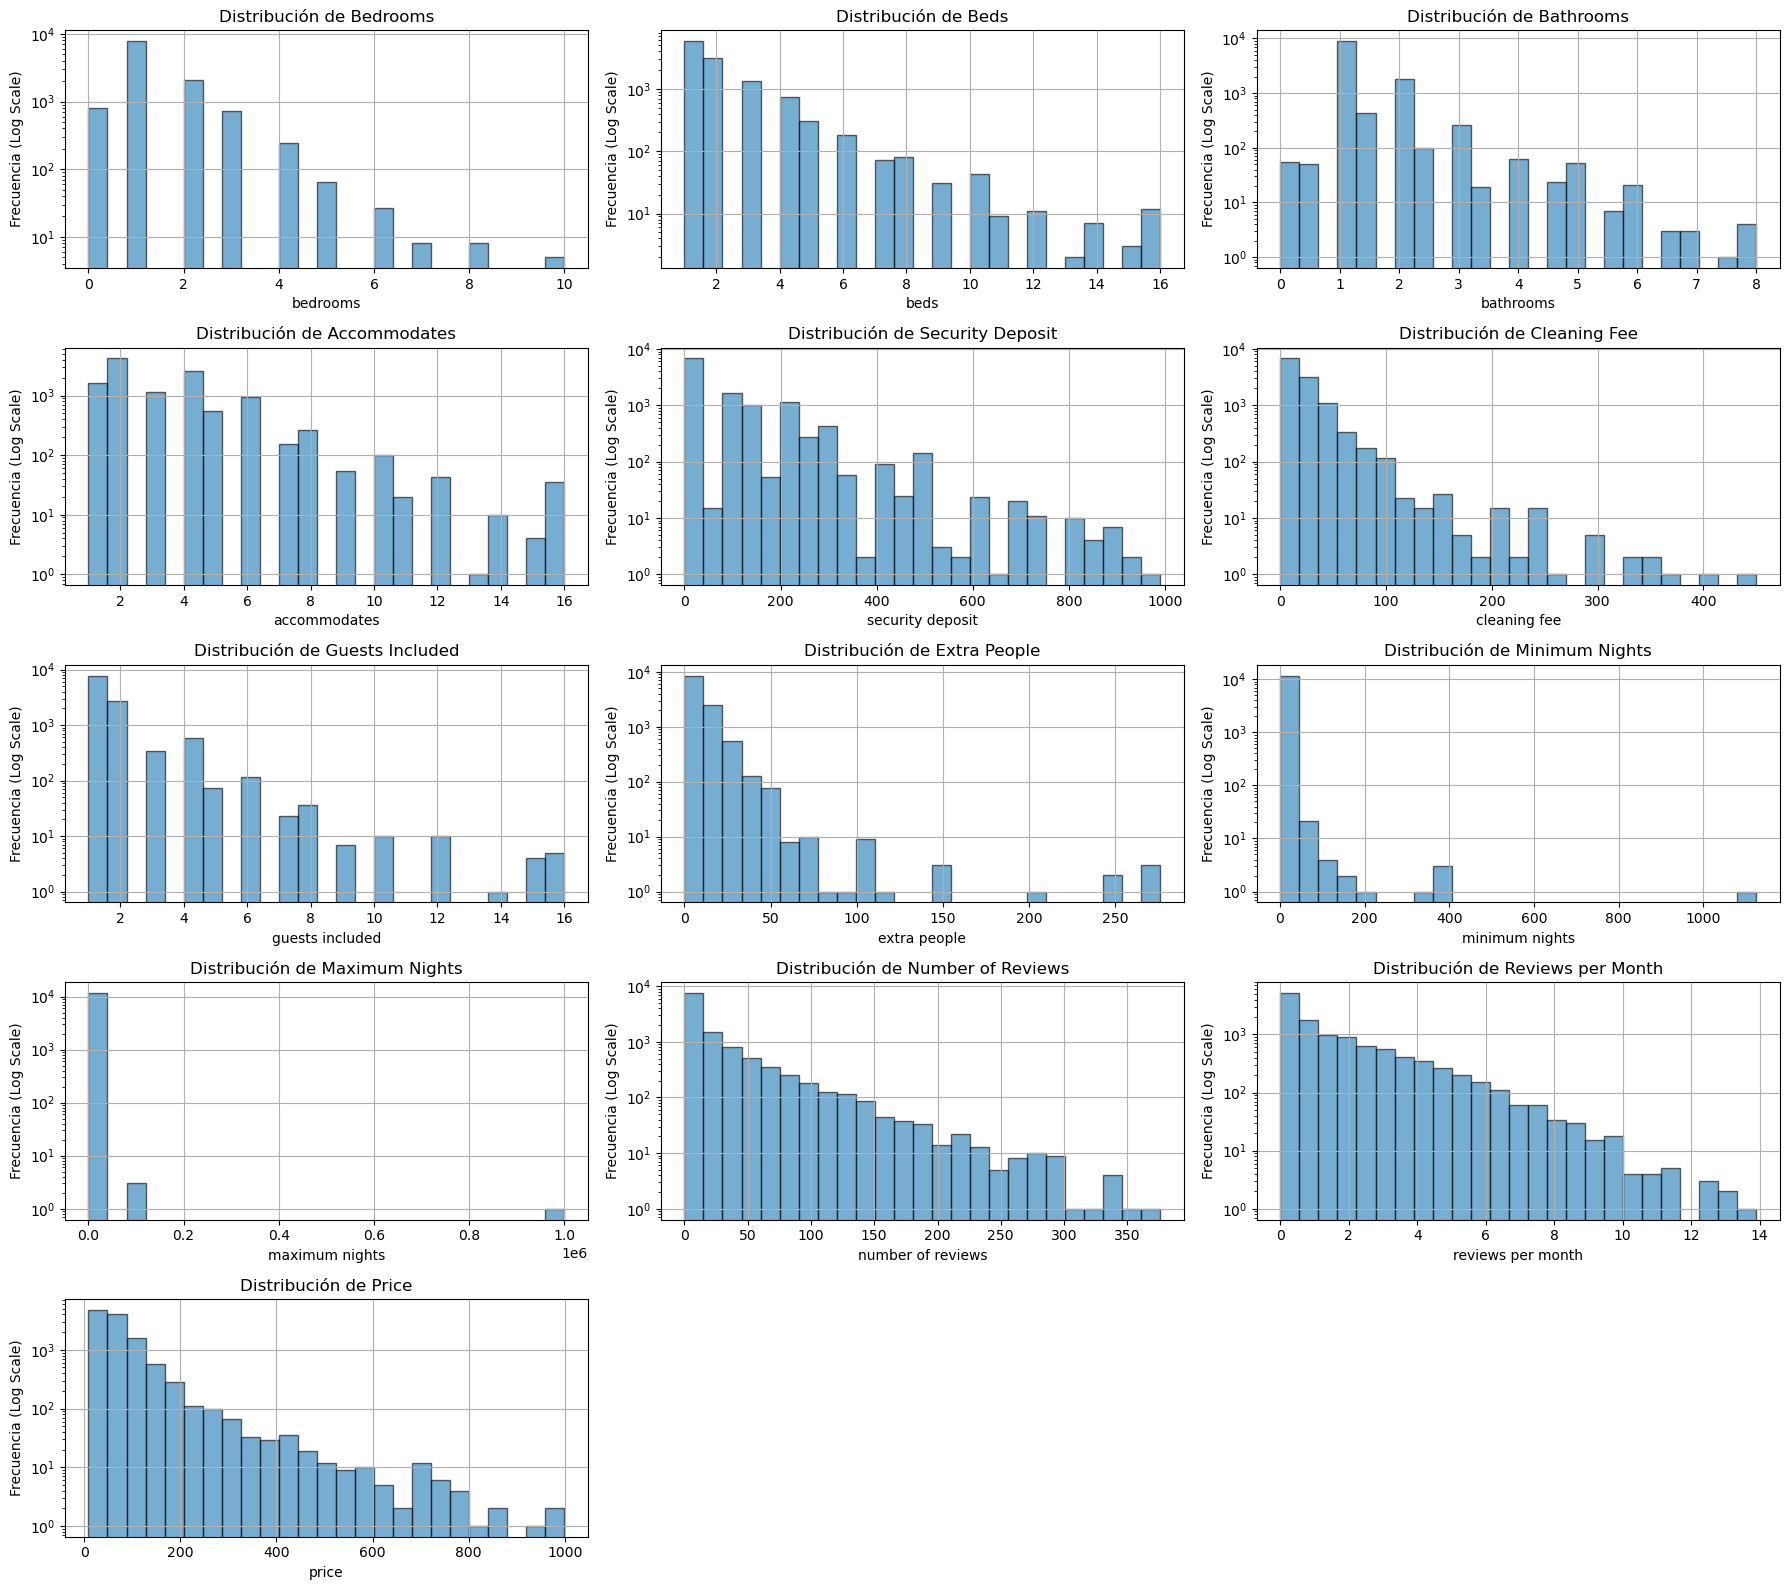

In [14]:

variables = [
    'Bedrooms', 'Beds', 'Bathrooms',                  
    'Accommodates', 'Security Deposit', 'Cleaning Fee',
    'Guests Included', 'Extra People', 
    'Minimum Nights', 'Maximum Nights', 
    'Number of Reviews', 'Reviews per Month','Price'
]

cols_grid = 3
rows_grid = (len(variables) + cols_grid - 1) // cols_grid 

plt.figure(figsize=(18, 16)) 

for i, col in enumerate(variables):
    if col in airbnb_train.columns:
        plt.subplot(rows_grid, cols_grid, i + 1)
        
        airbnb_train[col].plot.hist(alpha=0.6, bins=25, grid=True, edgecolor='black')
        
        plt.yscale("log")
        
        plt.title(f'Distribución de {col}', fontsize=12)
        plt.xlabel(col.lower())
        plt.ylabel('Frecuencia (Log Scale)')
    else:
        print(f"⚠️ Alerta: La columna '{col}' no existe en el DataFrame.")
plt.tight_layout()
plt.show()

Decidimos a partir de donde limpiamos outliers

In [15]:
airbnb_train_no_outliers = airbnb_train.query(
    "Bedrooms <= 8 and "
    "Beds <= 14 and "
    "Bathrooms <= 7 and "
    "`Security Deposit` <= 900 and "
    "`Cleaning Fee` <= 350 and "
    "`Guests Included` <= 12 and "
    "`Extra People` <= 120 and "
    "`Minimum Nights` <= 100 and "
    "`Maximum Nights` <= 2000 and "
    "`Number of Reviews` <= 350 and "
    "`Reviews per Month` <= 12 and"
    "`Price` <= 800"
)

Revisamos que no hayamos perdido un gran volumen de datos

In [16]:
print(airbnb_train.shape[0])
print(airbnb_train_no_outliers.shape[0])
print(f'Variación: {((airbnb_train.shape[0] - airbnb_train_no_outliers.shape[0])/airbnb_train_no_outliers.shape[0])*100:2f}%')

11812
11729
Variación: 0.707648%


In [17]:
airbnb_train_no_outliers.head(5)

,Host Response Time,Host Response Rate,Neighbourhood,Neighbourhood Cleansed,Neighbourhood Group Cleansed,Zipcode,Latitude,Longitude,Property Type,Room Type,...,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Cancellation Policy,Calculated host listings count,Reviews per Month,Features
0,Unknown,100.0,Unknown,Embajadores,Centro,28012,40.405830,-3.701767,Apartment,Entire home/apt,...,9.0,9.0,10.0,10.0,10.0,9.0,flexible,1.0,0.08,3
1,within an hour,100.0,Sol,Sol,Centro,28012,40.415465,-3.708185,Apartment,Private room,...,9.0,10.0,9.0,10.0,10.0,10.0,strict,4.0,3.69,4
2,within an hour,100.0,Unknown,Comillas,Carabanchel,28019,40.394185,-3.709676,Loft,Entire home/apt,...,9.0,9.0,9.0,9.0,9.0,8.0,strict,2.0,4.81,3
3,within an hour,100.0,Unknown,Universidad,Centro,28004,40.424610,-3.703497,Apartment,Shared room,...,10.0,10.0,10.0,10.0,10.0,10.0,flexible,1.0,2.47,4
4,within a few hours,100.0,La Latina,Palacio,Centro,28005,40.411804,-3.708933,House,Entire home/apt,...,9.0,10.0,10.0,10.0,10.0,10.0,moderate,3.0,4.58,5


Aplicamos One-Hot encoding a las variables categóricas de baja cardinalidad (como Room Type o Cancellation Policy), ya que generarán pocas columnas nuevas y no aumentarán excesivamente la dimensionalidad del dataset.

In [18]:
cols_one_hot = ['Host Response Time', 'Room Type', 'Bed Type', 'Cancellation Policy']
X_train_encoded = pd.get_dummies(airbnb_train_no_outliers, columns=cols_one_hot, drop_first=True)
X_train_encoded.head(5)

,Host Response Rate,Neighbourhood,Neighbourhood Cleansed,Neighbourhood Group Cleansed,Zipcode,Latitude,Longitude,Property Type,Accommodates,Bathrooms,...,Bed Type_Futon,Bed Type_Pull-out Sofa,Bed Type_Real Bed,Cancellation Policy_flexible_new,Cancellation Policy_moderate,Cancellation Policy_moderate_new,Cancellation Policy_strict,Cancellation Policy_strict_new,Cancellation Policy_super_strict_30,Cancellation Policy_super_strict_60
0,100.0,Unknown,Embajadores,Centro,28012,40.405830,-3.701767,Apartment,2,1.0,...,False,False,True,False,False,False,False,False,False,False
1,100.0,Sol,Sol,Centro,28012,40.415465,-3.708185,Apartment,3,1.0,...,False,False,True,False,False,False,True,False,False,False
2,100.0,Unknown,Comillas,Carabanchel,28019,40.394185,-3.709676,Loft,2,1.0,...,False,False,True,False,False,False,True,False,False,False
3,100.0,Unknown,Universidad,Centro,28004,40.424610,-3.703497,Apartment,2,1.0,...,False,False,True,False,False,False,False,False,False,False
4,100.0,La Latina,Palacio,Centro,28005,40.411804,-3.708933,House,3,1.0,...,False,False,True,False,True,False,False,False,False,False


Para las variables categóricas de alta cardinalidad (como Neighbourhood o Zipcode), aplicamos Target Encoding. Esto nos permite sustituir la categoría por el valor medio de la variable objetivo (el Precio) en ese barrio, capturando así su impacto predictivo sin disparar la dimensionalidad.

In [19]:

encoder = TargetEncoder(cols=['Neighbourhood', 'Neighbourhood Group Cleansed',
'Neighbourhood Cleansed','Zipcode','Property Type'])

encoder.fit(X_train_encoded.drop('Price', axis=1), X_train_encoded['Price'])

train_encoded = encoder.transform(X_train_encoded.drop('Price', axis=1))
train_encoded.head(5)


,Host Response Rate,Neighbourhood,Neighbourhood Cleansed,Neighbourhood Group Cleansed,Zipcode,Latitude,Longitude,Property Type,Accommodates,Bathrooms,...,Bed Type_Futon,Bed Type_Pull-out Sofa,Bed Type_Real Bed,Cancellation Policy_flexible_new,Cancellation Policy_moderate,Cancellation Policy_moderate_new,Cancellation Policy_strict,Cancellation Policy_strict_new,Cancellation Policy_super_strict_30,Cancellation Policy_super_strict_60
0,100.0,73.908720,59.612926,72.330922,66.377029,40.405830,-3.701767,71.576665,2,1.0,...,False,False,True,False,False,False,False,False,False,False
1,100.0,84.027972,84.239569,72.330922,66.377029,40.415465,-3.708185,71.576665,3,1.0,...,False,False,True,False,False,False,True,False,False,False
2,100.0,73.908720,35.286264,39.006897,38.628757,40.394185,-3.709676,77.218107,2,1.0,...,False,False,True,False,False,False,True,False,False,False
3,100.0,73.908720,68.289354,72.330922,73.776871,40.424610,-3.703497,71.576665,2,1.0,...,False,False,True,False,False,False,False,False,False,False
4,100.0,70.124224,78.154370,72.330922,67.232534,40.411804,-3.708933,95.323501,3,1.0,...,False,False,True,False,True,False,False,False,False,False


Miramos la matriz de correlación para revisar si tenemos que borrar alguna columna más

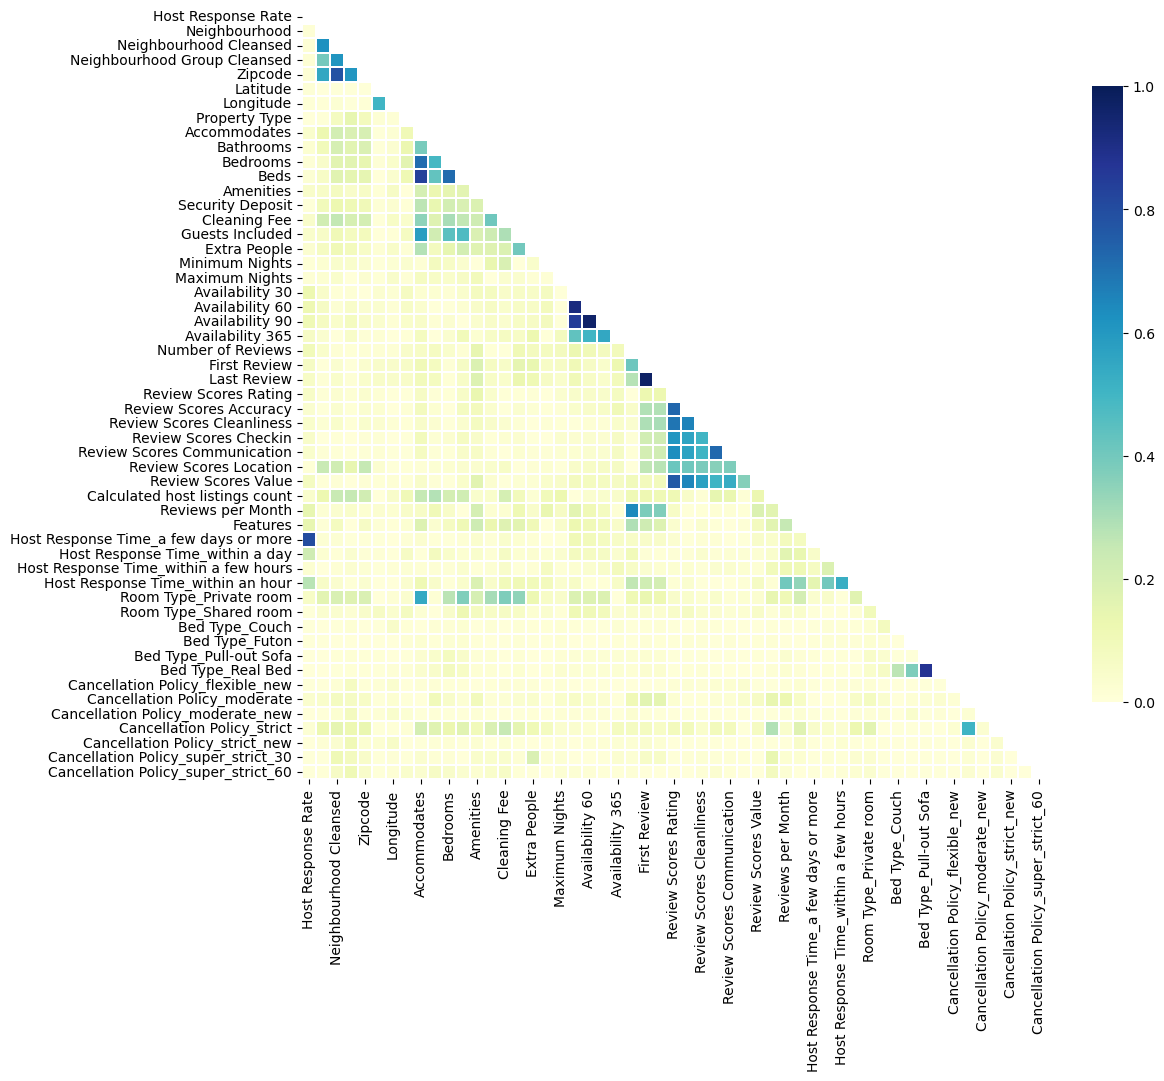

In [20]:

corr = np.abs(train_encoded.corr())

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()

Analizamos la matriz de correlación y detectamos multicolinealidad entre varias variables temporales y de disponibilidad (ej. Availability 60 y 90 están altamente correlacionadas con Availability 30). Para evitar redundancia y ruido en el modelo, eliminamos las variables menos representativas y conservamos solo las de mayor impacto.

In [21]:
train_encoded = train_encoded.drop(columns= [
    'Availability 60',
    'Availability 90',
    'First Review'
])



Volvemos a imprimir la matriz de correlación para volver a visualizarla

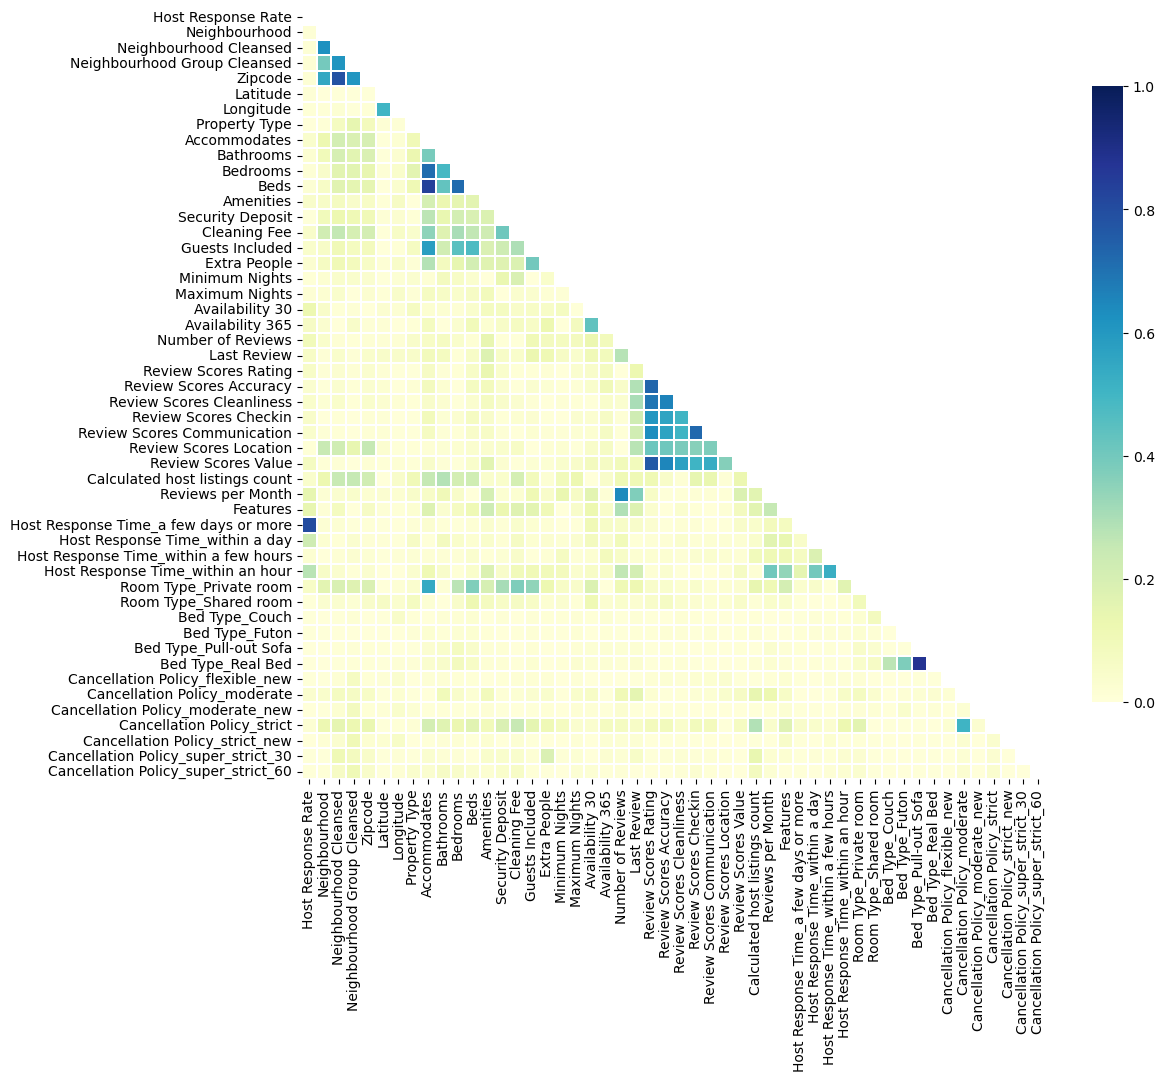

In [22]:

corr = np.abs(train_encoded.corr())

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()